Loading Training Data:
Found 50937 files belonging to 2 classes.

Loading Validation Data:
Found 16980 files belonging to 2 classes.

Class names assigned by TensorFlow: ['awake', 'sleepy']


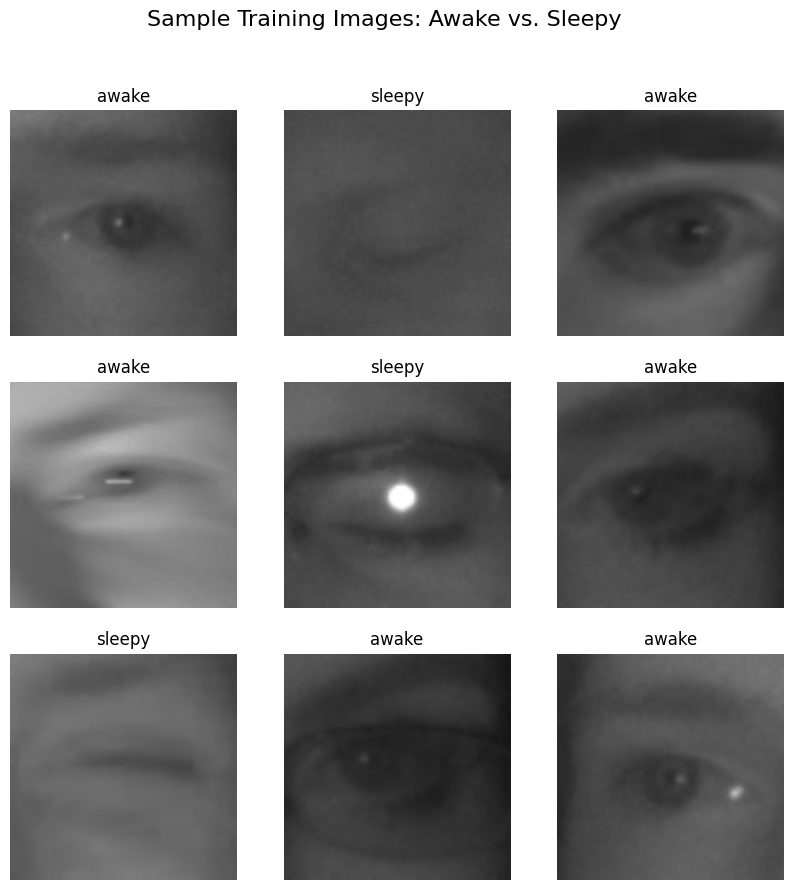

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Define your directories
train_dir = 'train'
val_dir = 'val'
test_dir = 'test'

# 2. Set the image size for MobileNetV2 and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 3. Load the datasets 
print("Loading Training Data:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

print("\nLoading Validation Data:")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# Extract the class names
class_names = train_dataset.class_names
print(f"\nClass names assigned by TensorFlow: {class_names}")

# 4. Data Visualization (Save this output for your report!)
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1): # Grab one batch of images
    for i in range(9): # Display the first 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
        
plt.suptitle("Sample Training Images: Awake vs. Sleepy", fontsize=16)
plt.show()

In [4]:
# 5. Load the Pre-trained MobileNetV2 Model (The "Body")
print("Downloading MobileNetV2...")
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), # The size we resized our images to!
    include_top=False,         # We drop the original 1,000 classes
    weights='imagenet'         # Use the powerful pre-trained weights
)

# Freeze the base model so we don't destroy its pre-trained knowledge
base_model.trainable = False

# 6. Add our custom classification head (The "Brain")
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2), # Drops 20% of neurons randomly to prevent overfitting
    tf.keras.layers.Dense(1, activation='sigmoid') # Binary output: closer to 0 (awake) or 1 (sleepy)
])

# 7. Compile the model (Telling it how to learn)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy', # Standard loss function for 2 classes
              metrics=['accuracy'])

print("\n✅ Model successfully built! Here is the architecture:")
model.summary()


✅ Model successfully built! Here is the architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
# 8. Train the Model
# An "Epoch" is one full pass through the entire dataset. 
# We'll start with 5. You can always increase this later to get better accuracy!
EPOCHS = 5 

print(f"Starting training for {EPOCHS} epochs... Your computer fans might get loud!")

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

# 9. Save the Brain!
# We save it so we don't have to retrain it every time we want to use the webcam later.a                                                    
model.save('drowsiness_model.h5')
print("\n✅ Training complete and model saved as 'drowsiness_model.h5'!")

Starting training for 5 epochs... Your computer fans might get loud!
Epoch 1/5
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 2767s 2s/step - accuracy: 0.8251 - loss: 0.4087 - val_accuracy: 0.8741 - val_loss: 0.3219
Epoch 2/5
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 3102s 2s/step - accuracy: 0.8812 - loss: 0.3020 - val_accuracy: 0.8945 - val_loss: 0.2668
Epoch 3/5
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 2576s 2s/step - accuracy: 0.8996 - loss: 0.2610 - val_accuracy: 0.9068 - val_loss: 0.2383
Epoch 4/5
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 2267s 1s/step - accuracy: 0.9096 - loss: 0.2357 - val_accuracy: 0.9158 - val_loss: 0.2177
Epoch 5/5
1592/1592 ━━━━━━━━━━━━━━━━━━━━ 3154s 2s/step - accuracy: 0.9162 - loss: 0.2188 - val_accuracy: 0.9245 - val_loss: 0.2001



✅ Training complete and model saved as 'drowsiness_model.h5'!


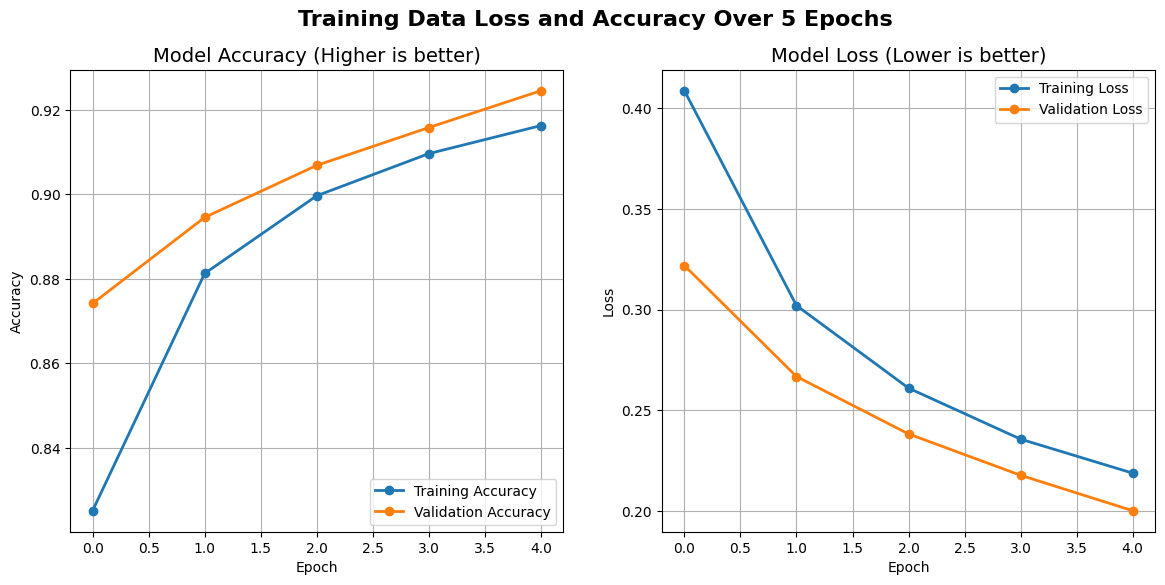

In [6]:
# 10. Plot Training & Validation Loss and Accuracy (Required for Deliverable b)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(14, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2, marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, marker='o')
plt.legend(loc='lower right')
plt.title('Model Accuracy (Higher is better)', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2, marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, marker='o')
plt.legend(loc='upper right')
plt.title('Model Loss (Lower is better)', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True) 

plt.suptitle("Training Data Loss and Accuracy Over 5 Epochs", fontsize=16, fontweight='bold')
plt.show()

Found 16980 files belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━

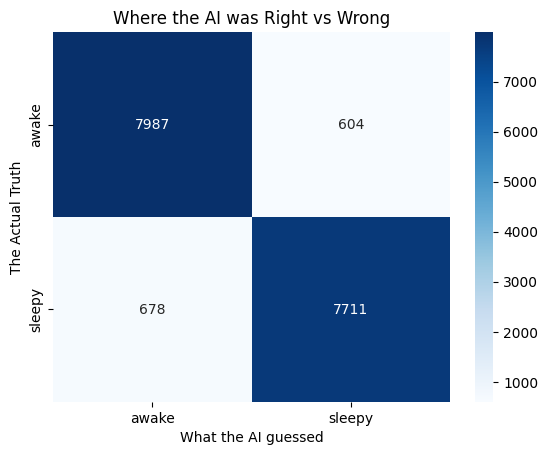

In [2]:
# --- STEP 11: TEST THE BRAIN ---
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get the images from the 'val' folder to test
test_data = tf.keras.utils.image_dataset_from_directory(
    'val', 
    shuffle=False, 
    image_size=(224, 224)
)

# 2. Get the real answers (True Labels) and the AI's guesses (Predictions)
true_answers = []
ai_guesses = []

for images, labels in test_data:
    # Save the real answers
    true_answers.extend(labels.numpy())
    
    # Ask the AI to guess
    raw_predictions = model.predict(images)
    
    # If the score is more than 0.5, the AI thinks it is 'sleepy' (1)
    # Otherwise, it thinks it is 'awake' (0)
    for p in raw_predictions:
        if p > 0.5:
            ai_guesses.append(1)
        else:
            ai_guesses.append(0)

# 3. Print the simple number report (Precision, Recall, F1)
# This satisfies the instructor's requirement for "Relevant Metrics"
print("--- AI PERFORMANCE REPORT ---")
names = ['awake', 'sleepy']
print(classification_report(true_answers, ai_guesses, target_names=names))

# 4. Draw the Confusion Matrix (The Blue Map)
# This shows exactly where the AI got confused
matrix = confusion_matrix(true_answers, ai_guesses)

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=names, yticklabels=names)
plt.title('Where the AI was Right vs Wrong')
plt.xlabel('What the AI guessed')
plt.ylabel('The Actual Truth')
plt.show()

WebCam Code

pygame 2.6.1 (SDL 2.28.4, Python 3.12.9)
Hello from the pygame community. https://www.pygame.org/contribute.html
Loading AI Brain...


⚠️ Warning: Could not find alarm.wav. Alarm will be silent.

🚨 WEBCAM TURNING ON! 🚨
--> Click on the video window that pops up, and press 'q' on your keyboard to stop it.

Camera safely turned off.


Loading AI Brain...



🚨 STABILIZED WEBCAM TURNING ON! 🚨
--> Click on the video window that pops up, and press 'q' on your keyboard to stop it.

Camera safely turned off.


In [4]:
import cv2
import numpy as np
import tensorflow as tf
import pygame 

print("Loading AI Brain...")
model = tf.keras.models.load_model('drowsiness_model.h5')

# --- AUDIO SETUP ---
pygame.mixer.init()
pygame.mixer.music.load('AlarmSound.mp3') 
is_alarm_playing = False
# ----------------------

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

cap = cv2.VideoCapture(0)
sleepy_frames = 0
ALARM_THRESHOLD = 5 
frame_counter = 0

# These variables hold the state so the screen doesn't flicker
display_label = "WAITING..."
display_color = (0, 255, 0)
x, y = 50, 50 # Default text position

print("\n🚨 STABILIZED WEBCAM TURNING ON! 🚨")
print("--> Click on the video window that pops up, and press 'q' on your keyboard to stop it.")

while True:
    ret, frame = cap.read()
    if not ret: 
        break

    frame_counter += 1
    
    # Only run the heavy detection math every 3rd frame to stop laptop lag!
    if frame_counter % 3 == 0:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

        # If no face is found at all, we assume the person fell completely over
        if len(faces) == 0:
            sleepy_frames += 1

        for (fx, fy, w, h) in faces:
            x, y = fx, fy # Update text position to track the face
            cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
            
            roi_gray = gray[y:y+h, x:x+w]
            roi_color = frame[y:y+h, x:x+w]
            
            eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=5)
            
            if len(eyes) == 0:
                # The camera lost the eye!
                sleepy_frames += 1
            else:
                for (ex, ey, ew, eh) in eyes:
                    cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)
                    
                    eye_roi = roi_color[ey:ey+eh, ex:ex+ew]
                    resized_eye = cv2.resize(eye_roi, (224, 224))
                    
                    # 🔥 CRUCIAL FIX 1: NO / 255.0! Matches your 92% accurate training data exactly.
                    img_array = tf.cast(tf.expand_dims(resized_eye, 0), tf.float32)
                    
                    prediction = model.predict(img_array, verbose=0)
                    score = prediction[0][0] 
                    
                    # 🔥 CRUCIAL FIX 2: Original working logic! 1 = Sleepy.
                    if score > 0.5: 
                        sleepy_frames += 1
                    else:
                        sleepy_frames = 0 # Eyes are open, reset the alarm timer!
                        
                    break # Process one eye to save CPU speed
                    
    # --- VISUAL STABILITY BUFFER ---
    if sleepy_frames >= 2:
        display_label = "SLEEPY"
        display_color = (0, 0, 255)
    else:
        display_label = "AWAKE"
        display_color = (0, 255, 0)
        
    # --- ALARM LOGIC ---
    if sleepy_frames >= ALARM_THRESHOLD:
        cv2.putText(frame, "ALARM: WAKE UP!", (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 3)
        if not is_alarm_playing:
            pygame.mixer.music.play(-1) 
            is_alarm_playing = True
    else:
        if is_alarm_playing:
            pygame.mixer.music.stop()
            is_alarm_playing = False
            
    cv2.putText(frame, display_label, (x, max(30, y-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.9, display_color, 2)
    cv2.imshow('Drowsiness Detection System', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
pygame.mixer.quit()
cv2.destroyAllWindows()
print("\nCamera safely turned off.")


Loading AI Brain...



🚨 STABILIZED WEBCAM TURNING ON! 🚨
--> Click on the video window that pops up, and press 'q' on your keyboard to stop it.

Camera safely turned off.
